In [ ]:
"""Image2text generation with BLIP and MarianMT."""

import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from transformers import logging
from transformers import MarianMTModel, MarianTokenizer
from transformers import BlipProcessor, BlipForConditionalGeneration

In [2]:
logging.set_verbosity_error()

In [3]:
TRANSLATOR_MODEL_NAME = "Helsinki-NLP/opus-mt-en-ru"
CAPTIONER_MODEL_NAME = "Salesforce/blip-image-captioning-{}"
CAPTIONER_MODEL_SIZE = "base"
WORK_DIR = "/Users/pasha/Sources/python/ml/cv/data/evaluate/detection"

In [4]:
def get_device() -> torch.device:
    device = None
    if torch.backends.mps.is_available():
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    return torch.device(device)


device = get_device()

### Translator


In [5]:
class Translator:
    def __init__(self, model_name: str, device: torch.device):
        self.tokenizer = MarianTokenizer.from_pretrained(model_name)
        self.model = MarianMTModel.from_pretrained(model_name).to(device)

    def translate_to_russian(self, text: str, max_length: int = 100) -> str:
        batch = self.tokenizer(text, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            generated = self.model.generate(**batch, max_length=max_length)
        return self.tokenizer.decode(generated[0], skip_special_tokens=True)

In [6]:
translator = Translator(TRANSLATOR_MODEL_NAME, device)

### Captioner


In [7]:
class Captioner:
    def __init__(self, model_name: str):
        self.processor = BlipProcessor.from_pretrained(model_name)
        self.model = BlipForConditionalGeneration.from_pretrained(model_name).to(device)
        self.model.eval()

    def run(
        self, image: Image.Image, max_length: int = 50, num_beams: int = 5
    ) -> tuple[str, str] | None:
        if image is None:
            return None

        inputs = self.processor(image, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            if device.type == "mps":
                with torch.amp.autocast(device_type="mps", dtype=torch.float16):
                    out = self.model.generate(
                        **inputs, max_length=max_length, num_beams=num_beams
                    )
            else:
                out = self.model.generate(
                    **inputs, max_length=max_length, num_beams=num_beams
                )

        caption_en = self.processor.decode(out[0], skip_special_tokens=True)
        caption_ru = translator.translate_to_russian(caption_en)
        return caption_en, caption_ru

In [8]:
captioner = Captioner(CAPTIONER_MODEL_NAME.format(CAPTIONER_MODEL_SIZE))

### Demo


In [9]:
class PlotStyle:
    width: int = 5
    height: int = 5
    point_color: str = "red"
    point_size: int = 40
    segment_alpha: float = 0.4


def show(
    image: np.ndarray,
    style: PlotStyle,
) -> None:
    fig, axes = plt.subplots(1, 1, figsize=(style.width, style.height))
    fig.patch.set_visible(False)
    axes.axis("off")
    axes.imshow(image)

In [10]:
def generate_caption(fn: str) -> None:
    path = os.path.join(WORK_DIR, fn)

    img = Image.open(path).convert("RGB")
    cap_en, cap_ru = captioner.run(img)

    print("En: %s\nRu: %s" % (cap_en.capitalize(), cap_ru.capitalize()))
    style = PlotStyle()
    show(img, style)

En: A red apple with a green leaf on top
Ru: Красное яблоко с зеленым листом сверху


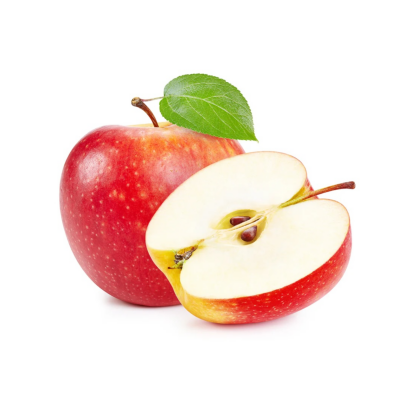

In [11]:
generate_caption("2.jpg")

En: Various types of cheese on a wooden board
Ru: Различные виды сыра на деревянной доске


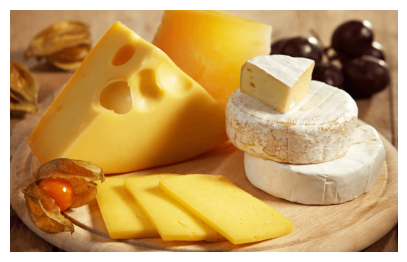

In [12]:
generate_caption("3.jpg")

En: Two mugs of beer on a wooden table
Ru: Две кружки пива на деревянном столе


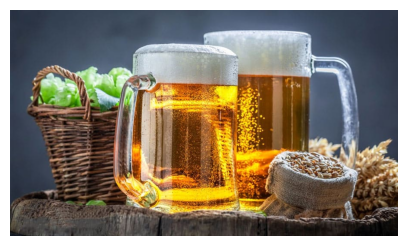

In [13]:
generate_caption("7.jpg")

En: A plate of spaghetti with tomato sauce and basil
Ru: Тарелка спагетти с томатным соусом и базиликом


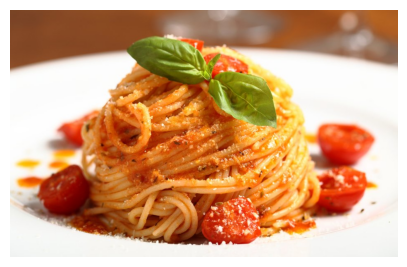

In [14]:
generate_caption("9.jpg")

En: A taco taco taco taco taco taco taco taco taco taco taco taco taco ta
Ru: Тако тако тако тако тако тако тако тако тако тако тако тако тако тако тако


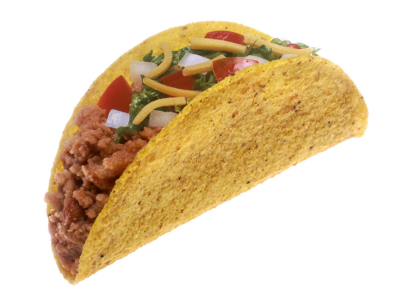

In [15]:
generate_caption("11.jpg")